## 1. Import & Setup
Load the dataset and immediately convert the timestamp column to a datetime object.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sympy import false

# Set visualization style for executive report
sns.set_theme(style="whitegrid", context="talk")

# Set up directories using pathlib
current_dir = Path().resolve()
project_root = current_dir.parent

data_dir = project_root / "data"
output_dir = project_root / "output"
output_dir.mkdir(parents=True, exist_ok=True)

# Load the dataset
file_path = data_dir / "nsp_electricity_dataset.csv"
df = pd.read_csv(file_path)

# Convert the timestamp column to a datetime object immediately
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (438360, 27)


## 2. Structural Inspection
Display the dataframe's info(), head(), and check for any missing values across all columns.

In [2]:
# Display the dataframe's info
print("--- Dataframe Info ---")
df.info()

# Display the first few rows
print("\n--- First 5 Rows ---")
display(df.head().T)

# Check for missing values across all columns
print("\n--- Missing Values Check ---")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print(missing_values[missing_values > 0])

--- Dataframe Info ---
<class 'pandas.DataFrame'>
RangeIndex: 438360 entries, 0 to 438359
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   timestamp         438360 non-null  datetime64[us]
 1   region            438360 non-null  str           
 2   hour              438360 non-null  int64         
 3   day_of_week       438360 non-null  int64         
 4   month             438360 non-null  int64         
 5   year              438360 non-null  int64         
 6   week              438360 non-null  int64         
 7   is_weekend        438360 non-null  int64         
 8   season            438360 non-null  str           
 9   is_holiday        438360 non-null  int64         
 10  temperature_c     438360 non-null  float64       
 11  feels_like_c      438360 non-null  float64       
 12  humidity_pct      438360 non-null  float64       
 13  wind_speed_kmh    438360 non-null  float64     

,0,1,2,3,4
timestamp,2015-01-01 00:00:00,2015-01-01 00:00:00,2015-01-01 00:00:00,2015-01-01 00:00:00,2015-01-01 00:00:00
region,Annapolis Valley,Cape Breton,Halifax,Pictou County,South Shore
hour,0,0,0,0,0
day_of_week,3,3,3,3,3
month,1,1,1,1,1
year,2015,2015,2015,2015,2015
week,1,1,1,1,1
is_weekend,0,0,0,0,0
season,Winter,Winter,Winter,Winter,Winter
is_holiday,1,1,1,1,1



--- Missing Values Check ---
No missing values found in the dataset.


## 3. Statistical Verification
Generate descriptive statistics for all numerical columns (specifically looking at the range of consumption_kwh and weather variables). Identify any potential outliers where values are more than 3 standard deviations from the mean.

In [3]:
# Generate descriptive statistics for numerical columns
print("--- Descriptive Statistics ---")
display(df.describe().T)

# Identify potential outliers (> 3 standard deviations from the mean) for numerical columns
print("--- Outliers Detection (> 3 Std Dev) ---")
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

outliers_summary = {}
for col in numerical_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    
    # Compute upper and lower bounds
    lower_bound = mean_val - (3 * std_val)
    upper_bound = mean_val + (3 * std_val)
    
    # Find outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        outliers_summary[col] = len(outliers)
        
for col, count in outliers_summary.items():
    print(f"Column '{col}': {count} potential outliers ({(count/len(df))*100:.2f}% of data)")

--- Descriptive Statistics ---


,count,mean,min,25%,50%,75%,max,std
timestamp,438360,2020-01-01 11:30:00,2015-01-01 00:00:00,2017-07-02 05:45:00,2020-01-01 11:30:00,2022-07-02 17:15:00,2024-12-31 23:00:00,NaN
hour,438360.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922194
day_of_week,438360.0,3.000274,0.0,1.0,3.0,5.0,6.0,2.000208
month,438360.0,6.52231,1.0,4.0,7.0,10.0,12.0,3.448877
year,438360.0,2019.500411,2015.0,2017.0,2020.0,2022.0,2024.0,2.872666
week,438360.0,26.608541,1.0,14.0,27.0,40.0,53.0,15.064876
is_weekend,438360.0,0.285792,0.0,0.0,0.0,1.0,1.0,0.451792
is_holiday,438360.0,0.030112,0.0,0.0,0.0,0.0,1.0,0.170896
temperature_c,438360.0,9.812542,-47.2,2.6,11.2,18.7,43.1,11.930775
feels_like_c,438360.0,9.531558,-48.3,2.6,11.2,18.7,45.2,12.755932


--- Outliers Detection (> 3 Std Dev) ---
Column 'is_holiday': 13200 potential outliers (3.01% of data)
Column 'temperature_c': 1164 potential outliers (0.27% of data)
Column 'feels_like_c': 991 potential outliers (0.23% of data)
Column 'humidity_pct': 662 potential outliers (0.15% of data)
Column 'wind_speed_kmh': 994 potential outliers (0.23% of data)
Column 'precipitation_mm': 8705 potential outliers (1.99% of data)
Column 'renewable_pct': 184 potential outliers (0.04% of data)
Column 'consumption_kwh': 7948 potential outliers (1.81% of data)
Column 'price_per_kwh': 5 potential outliers (0.00% of data)
Column 'grid_load_pct': 19 potential outliers (0.00% of data)
Column 'co2_kg': 9981 potential outliers (2.28% of data)
Column 'demand_response': 611 potential outliers (0.14% of data)
Column 'power_outage': 1114 potential outliers (0.25% of data)
Column 'anomaly_flag': 9053 potential outliers (2.07% of data)
Column 'peak_demand_flag': 21918 potential outliers (5.00% of data)


## 4. Target Visualization
Plot a histogram of consumption_kwh using a log scale for the Y-axis to visualize the frequency of extreme demand spikes. Save the figure to the output directory.

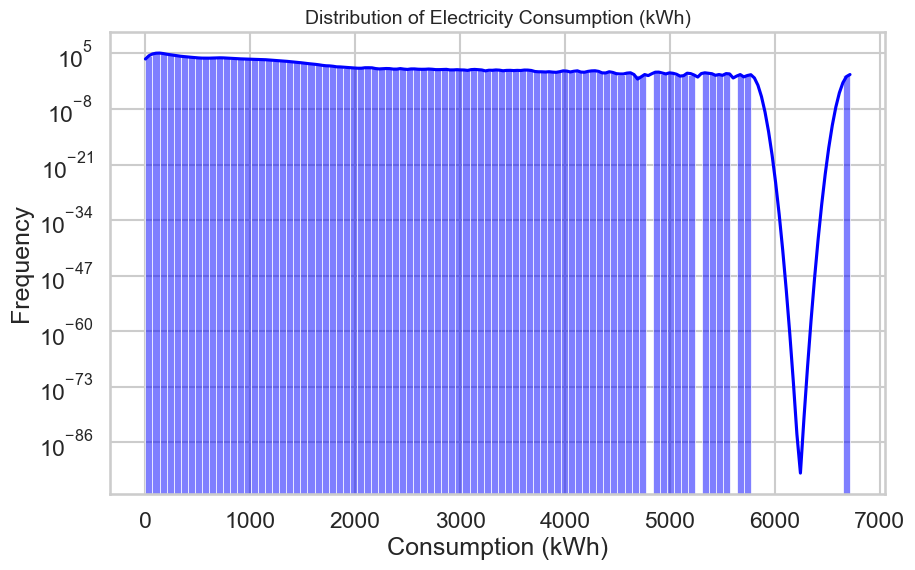

In [4]:
# 1. Distribution of Consumption (Numerical with High Skew)
plt.figure(figsize=(10, 6))
sns.histplot(df['consumption_kwh'], bins=100, kde=True, color='blue')
plt.title('Distribution of Electricity Consumption (kWh)', fontsize=14)
plt.xlabel('Consumption (kWh)')
plt.ylabel('Frequency')
plt.yscale('log') # Log scale to see the tail better given the high Kurtosis
plt.savefig(output_dir / 'consumption_dist.png')
plt.show()

### The "Long Tail" of Electricity Consumption
Look at the Electricity Consumption histogram. You'll notice it's heavily skewed to the right.

- The Insight: Most of the time, consumption stays in a lower, predictable range (the high peak on the left). However, the "tail" stretches far to the right, representing those rare but critical moments of extreme high demand (spikes).

- Scientific Note: This is high Kurtosis. It tells us that our electrical grid must be built to handle these extreme "outlier" events, even if they don't happen often.

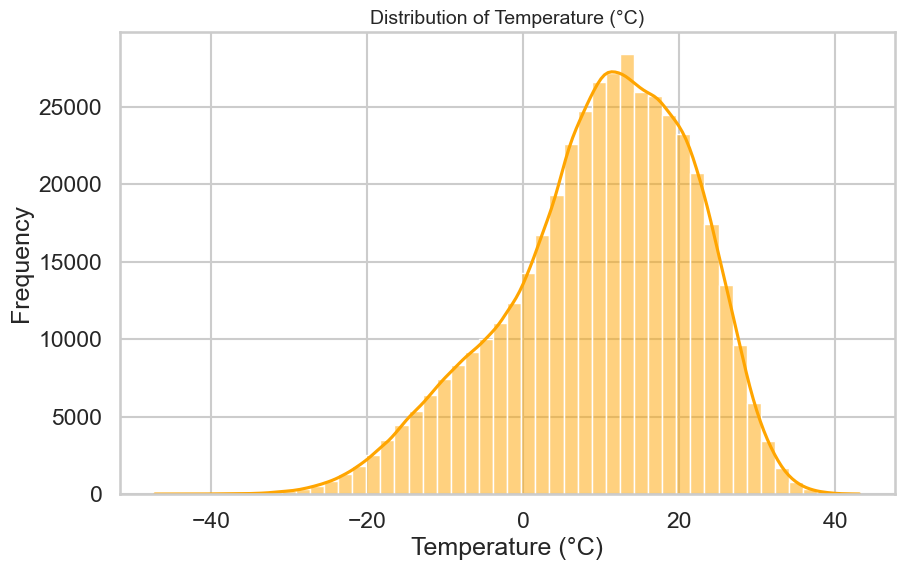

In [5]:
# 2. Distribution of Temperature (Weather Pattern)
plt.figure(figsize=(10, 6))
sns.histplot(df['temperature_c'], bins=50, kde=True, color='orange')
plt.title('Distribution of Temperature (°C)', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.savefig(output_dir / 'temperature_dist.png')
plt.show()

### The Weather Pattern
The Temperature distribution shows a bell-like curve but with a wide spread.
- The Insight: Unlike consumption, temperature is more "normally" distributed but covers a vast range (from deep freeze to summer heat).
- Scientific Note: The spread (variance) here is key for energy forecasting. We can see that the grid operates in temperatures ranging from $-40^\circ C$ to over $+40^\circ C$, requiring highly resilient infrastructure.

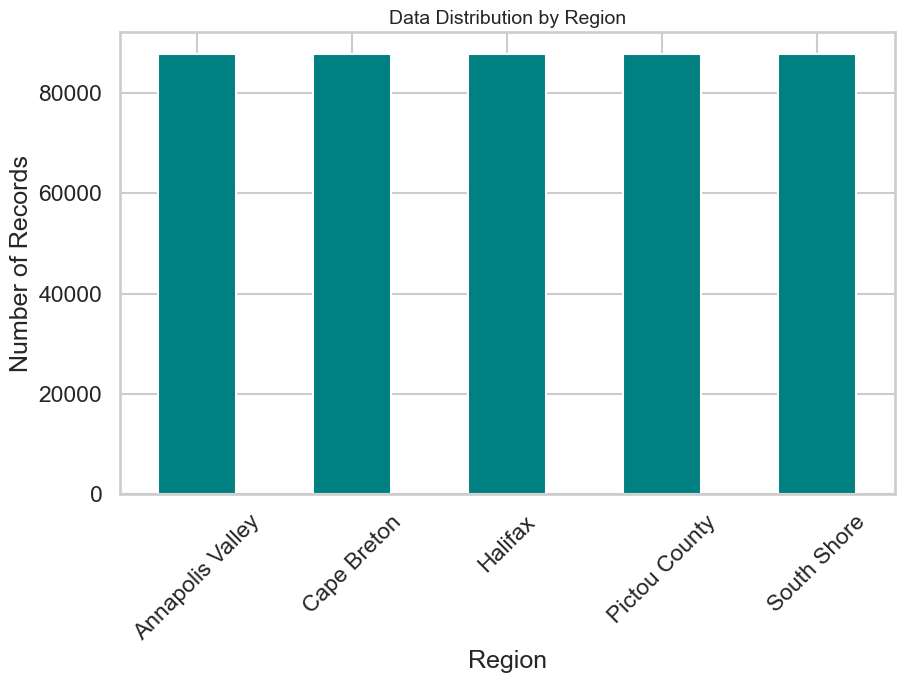

In [6]:
# 3. Region Distribution (Balance check)
plt.figure(figsize=(10, 6))
df['region'].value_counts().plot(kind='bar', color='teal')
plt.title('Data Distribution by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.savefig(output_dir / 'region_dist.png')
plt.show()

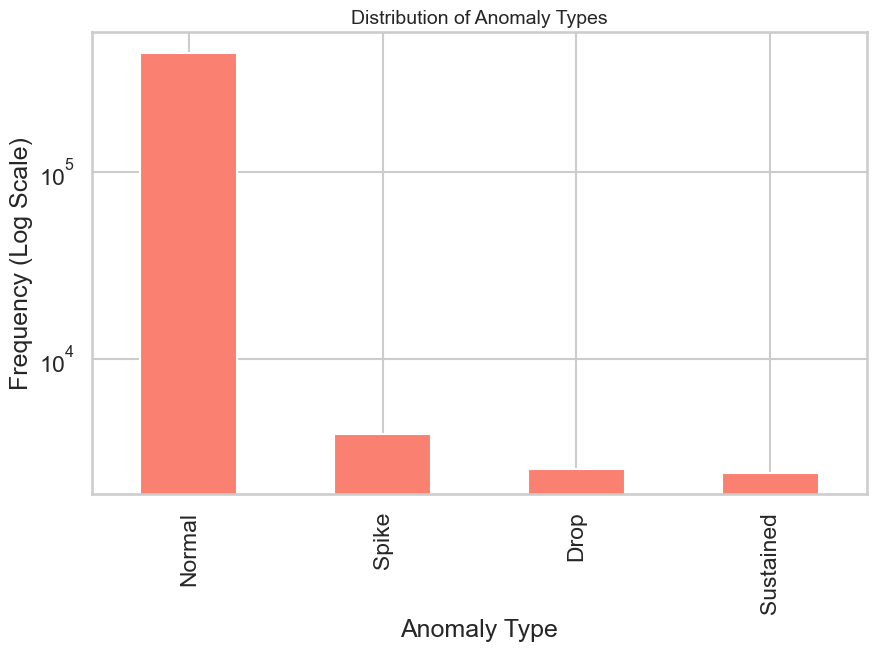

In [7]:
# 4. Anomaly Type Distribution (Imbalance check)
plt.figure(figsize=(10, 6))
anomaly_counts = df['anomaly_type'].value_counts()
anomaly_counts.plot(kind='bar', color='salmon')
plt.title('Distribution of Anomaly Types', fontsize=14)
plt.xlabel('Anomaly Type')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log')
plt.savefig(output_dir / 'anomaly_dist.png')
plt.show()

### Balanced vs. Imbalanced Data
Data balance is crucial for training fair machine learning models.

- Region (Balanced): The bar chart for Region shows five identical bars. This is a "Uniform Distribution." It means we have an equal amount of data for Halifax as we do for Cape Breton. This is perfect—it ensures our analysis isn't biased toward one city.

- Anomaly Type (Imbalanced): Contrast that with the Anomaly Type chart (on a log scale). The "Normal" bar towers over the others.

- Scientific Note: This is a classic Class Imbalance problem. Since anomalies like "Spikes" or "Power Outages" are so rare (less than 1%), we have to use specialized techniques to "teach" an AI how to recognize them.

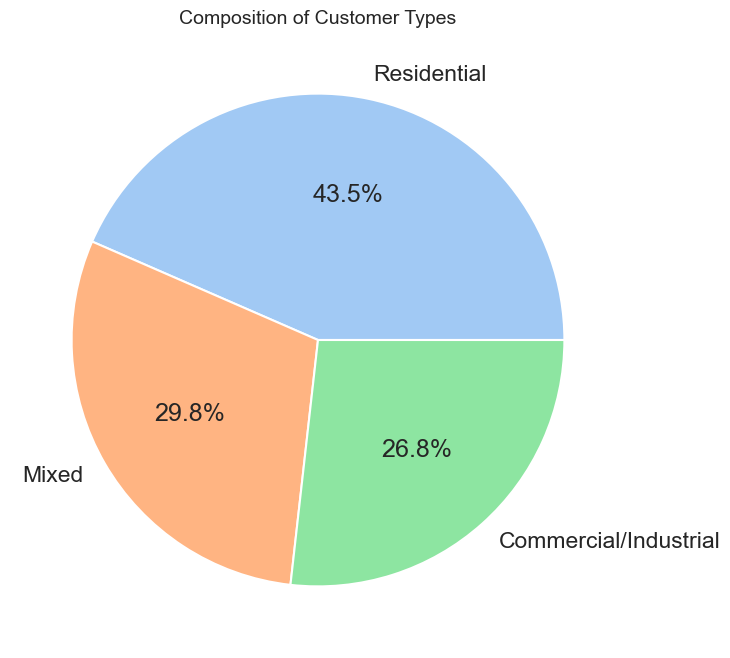

In [8]:
# 5. Customer Type Composition
plt.figure(figsize=(8, 8))
df['customer_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Composition of Customer Types', fontsize=14)
plt.ylabel('')
plt.savefig(output_dir / 'customer_pie.png')
plt.show()

### Who is using the power?
The Customer Type pie chart gives us a snapshot of the grid's "clientele."
- The Insight: Residential users are the primary drivers of demand ($43.5\%$).
- Scientific Note: Because residential usage is often tied to human behavior (waking up, cooking dinner), we expect strong daily cycles in this dataset.

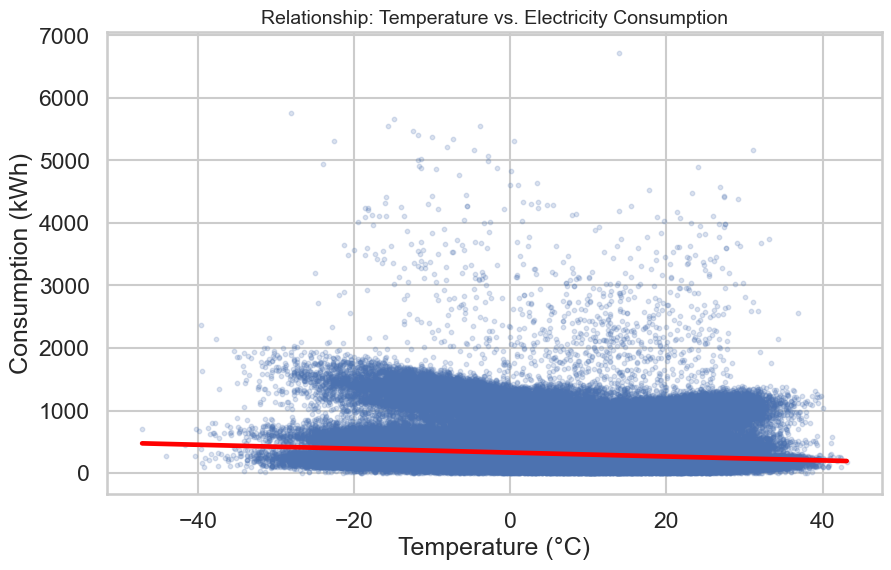

In [13]:
# 1. Temperature vs Consumption (The Weather Factor)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='temperature_c', y='consumption_kwh', 
            scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'})
plt.title('Relationship: Temperature vs. Electricity Consumption', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Consumption (kWh)')
plt.savefig(output_dir / 'temp_vs_consumption.png')
plt.show()

### Temperature vs. Usage (The "Heating" Effect)
When we look at Temperature vs. Consumption, we see a clear trend.

- The Simple Insight: As it gets colder (moving left on the graph), electricity usage goes up.

- Why it matters: This suggests that many customers likely use electric heating. The red line shows the general "downward" slope—warmer weather generally means lower power bills for the region.

- The Outliers: Notice the dots scattered way above the line? Those are the "spikes" we discussed earlier, occurring even in mild weather, likely due to industrial activity or grid anomalies.

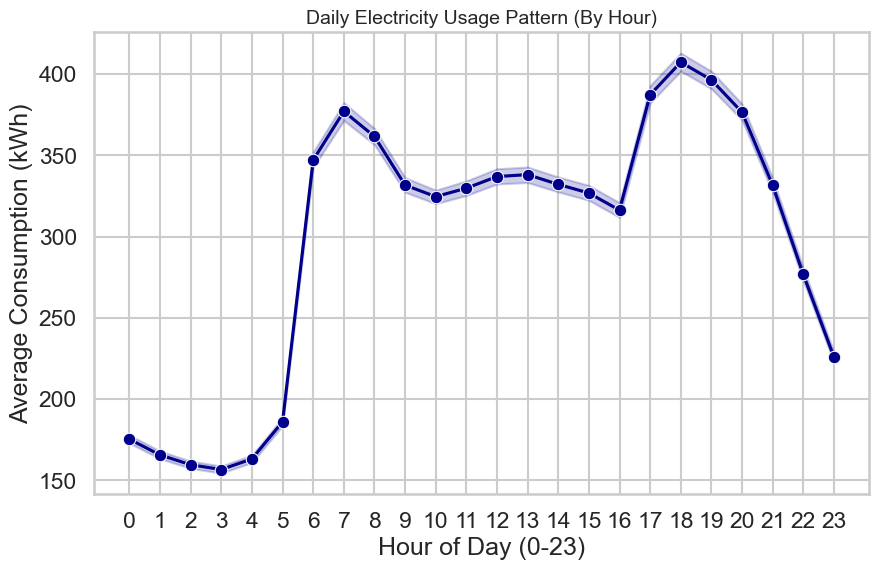

In [15]:
# 2. Time of Day (Hour) vs Consumption (The Daily Routine)
plt.figure(figsize=(10, 6))
hourly_avg = df.groupby('hour')['consumption_kwh'].mean().reset_index()
sns.lineplot(data=df, x='hour', y='consumption_kwh', color='darkblue', marker='o')
plt.title('Daily Electricity Usage Pattern (By Hour)', fontsize=14)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Consumption (kWh)')
plt.xticks(range(0, 24))
plt.savefig(output_dir / 'hour_vs_consumption.png')
plt.show()

### The Daily Heartbeat (Usage by Hour)
This line chart shows the Average Consumption by Hour of the day.

- The Simple Insight: People use the most power at 7:00 AM (waking up) and 6:00 PM (coming home/dinner).

- Why it matters: Usage is lowest in the middle of the night (3:00 AM). The "Double Hump" pattern is the classic heartbeat of a residential-heavy grid. This is when the grid is under the most stress.

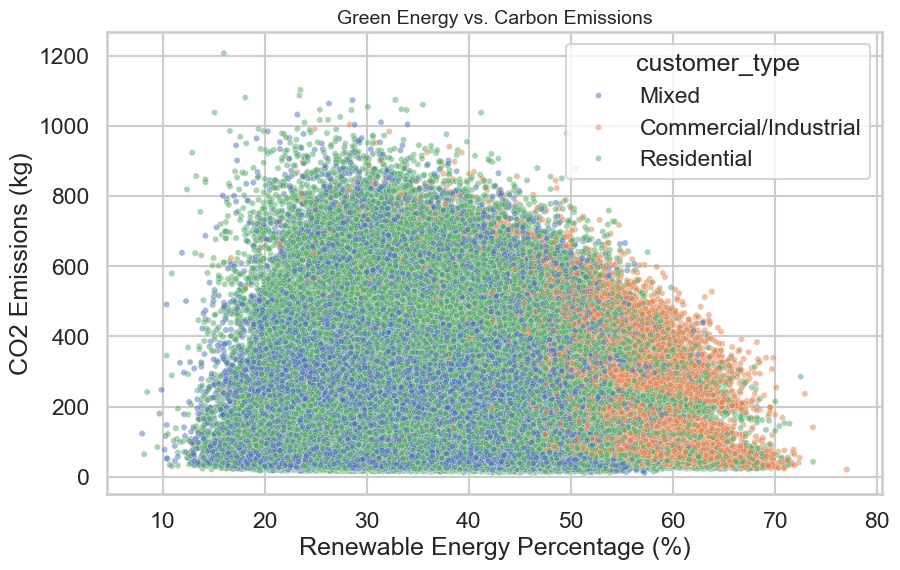

In [16]:
# 3. Renewable % vs CO2 (Environmental Impact)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='renewable_pct', y='co2_kg', hue='customer_type', alpha=0.5, s=20)
plt.title('Green Energy vs. Carbon Emissions', fontsize=14)
plt.xlabel('Renewable Energy Percentage (%)')
plt.ylabel('CO2 Emissions (kg)')
plt.savefig(output_dir / 'renewable_vs_co2.png')
plt.show()

### Green Energy vs. Pollution
We compared Renewable Energy % against CO2 Emissions.

- The Simple Insight: The dots trend downward to the right. This means when we use more wind/solar/hydro (Renewables), our carbon footprint (CO2) drops significantly.

- Why it matters: It proves that our green energy initiatives are working. Notice the different colored dots—Commercial/Industrial users (green) often have a much higher footprint than Residential users (orange), even when green energy is high.

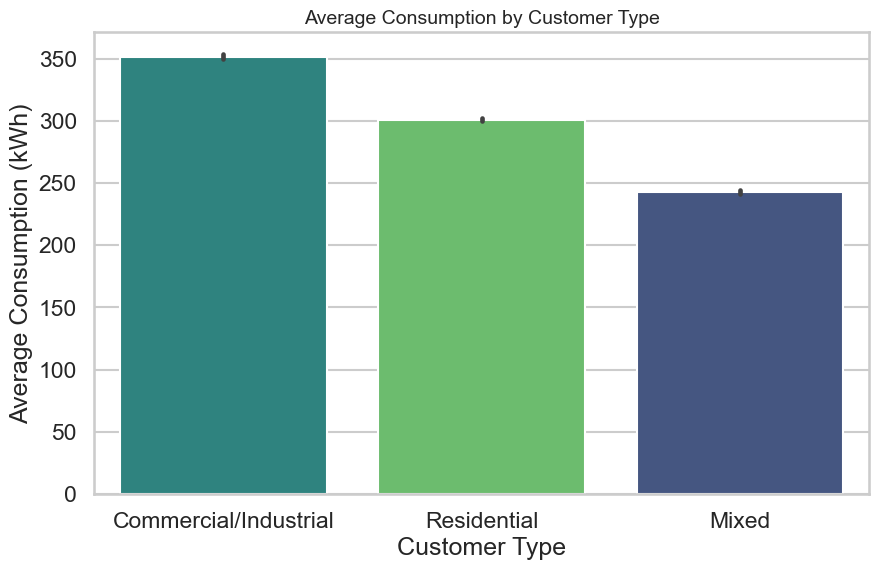

In [18]:
# 4. Customer Type vs Average Consumption (The Heavy Hitters)
plt.figure(figsize=(10, 6))
order = df.groupby('customer_type')['consumption_kwh'].mean().sort_values(ascending=False).index
sns.barplot(data=df, hue='customer_type', x='customer_type', y='consumption_kwh', palette='viridis', order=order, legend=False)
plt.title('Average Consumption by Customer Type', fontsize=14)
plt.xlabel('Customer Type')
plt.ylabel('Average Consumption (kWh)')
plt.savefig(output_dir / 'customer_vs_consumption.png')
plt.show()

### Who uses the most power?
The bar chart for Customer Type shows the average "size" of a typical power bill.

- The Simple Insight: On average, a single Commercial/Industrial connection uses more power than a Residential one.

- Why it matters: While there are more residents, the industrial sector is the "heavy hitter." If we need to save a lot of energy quickly (during a shortage), the biggest impact comes from working with industrial partners first.

## Summary for Decision Makers:
1. Prepare for the Cold: Ensure the grid has extra capacity when temperatures drop below $0^\circ C$.
2. Manage the Peak: Focus energy-saving programs on the 6:00 PM peak to reduce grid stress.
3. Invest in Green: Increasing renewable energy by even $10\%$ has a massive, visible impact on lowering CO2 levels across all customer types.

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

<Figure size 1200x1000 with 0 Axes>

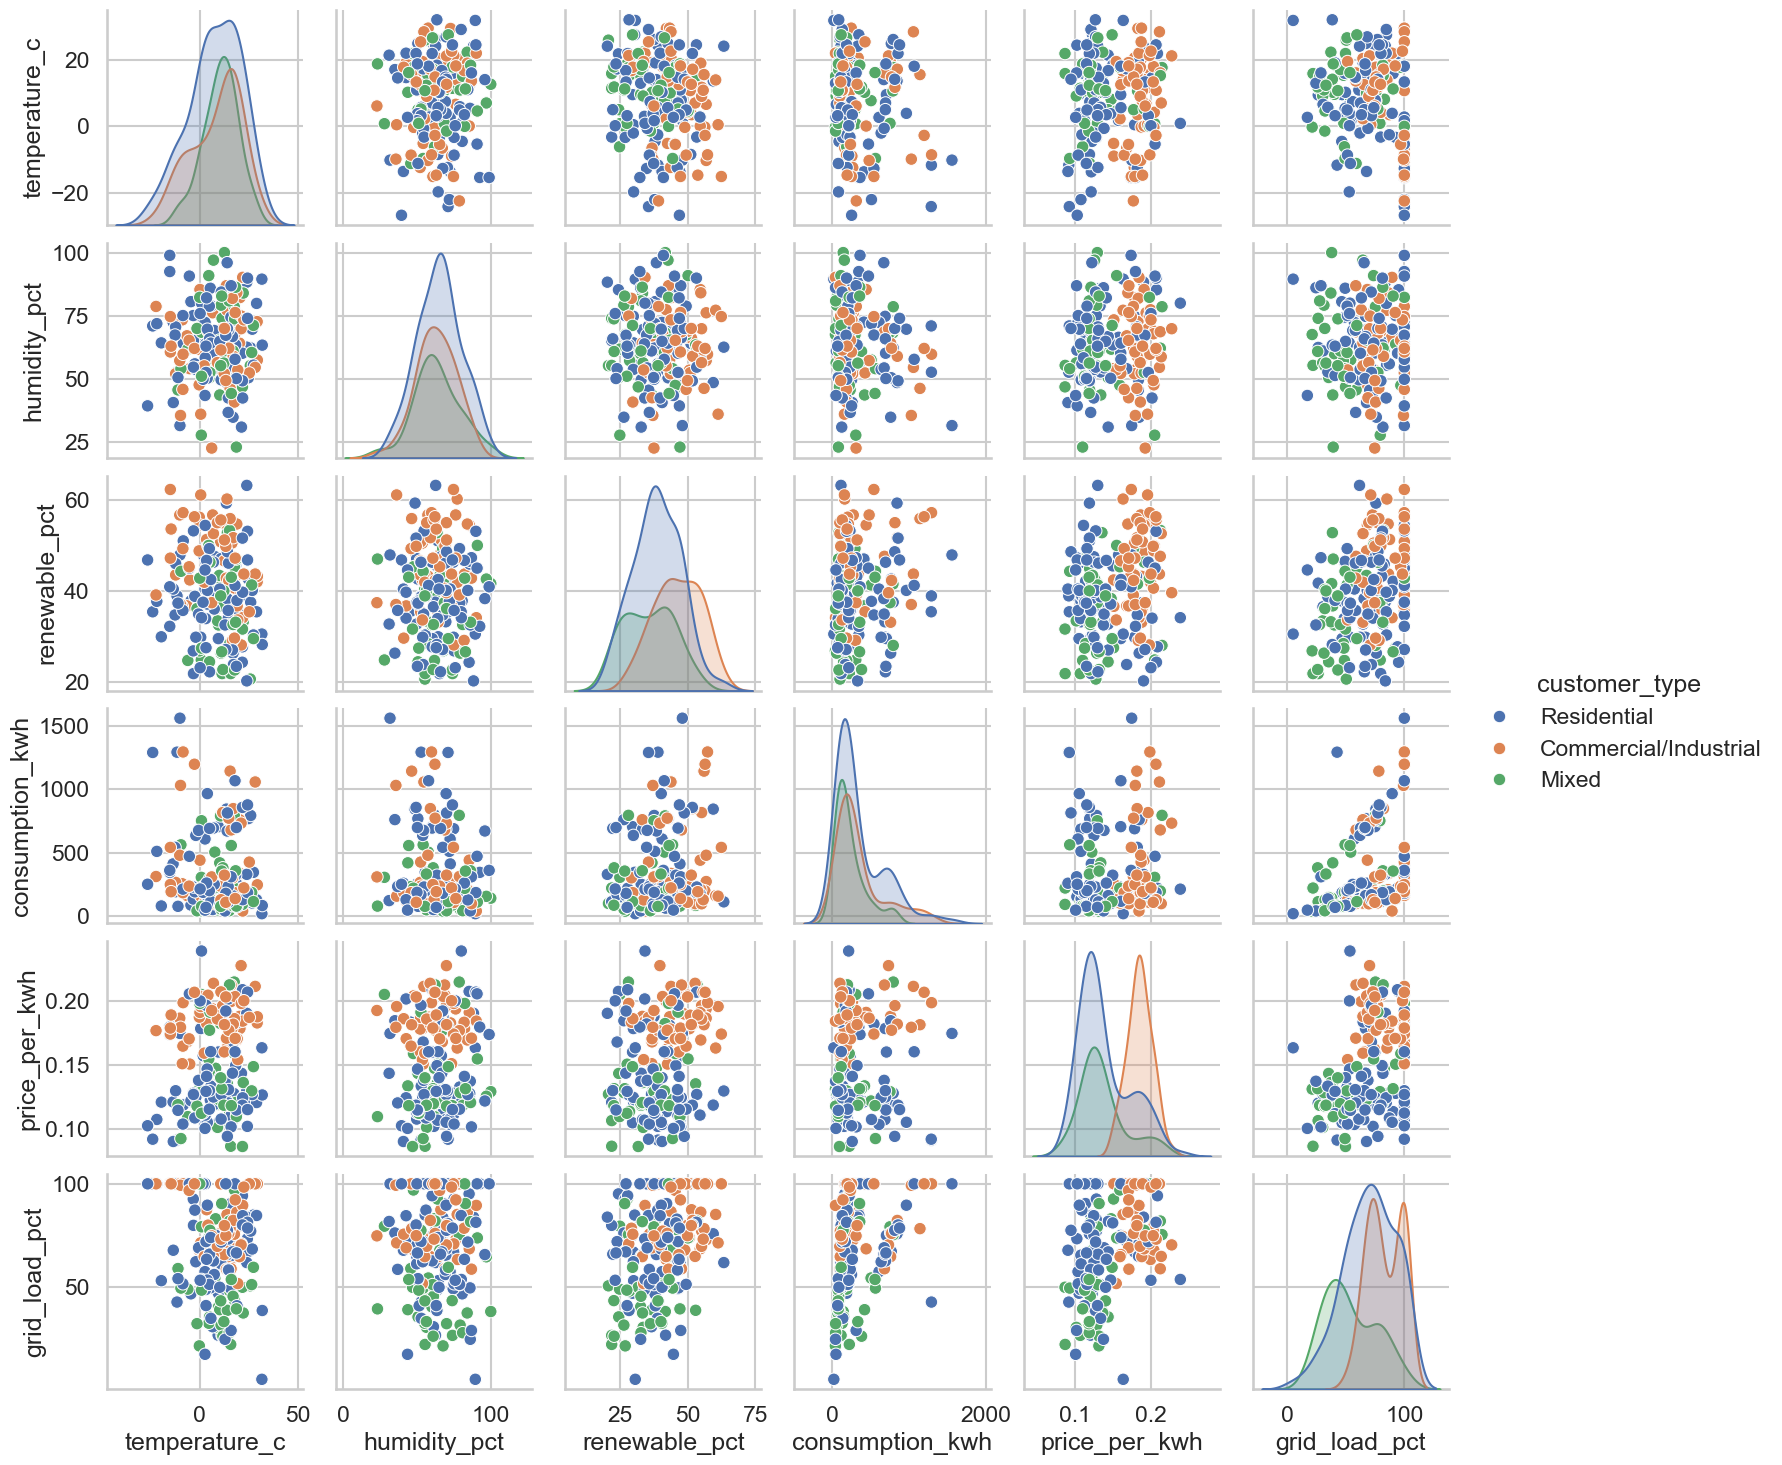

In [15]:
# 1. Pair Plot (Sampled for performance)
numerical_cols = ['temperature_c', 'humidity_pct', 'renewable_pct', 'consumption_kwh', 'price_per_kwh', 'grid_load_pct']

plt.figure(figsize=(12, 10))
sns.pairplot(df.sample(200)[numerical_cols + ['customer_type']], hue='customer_type', diag_kind='kde')
plt.savefig(output_dir / 'pair_plot.png')
plt.show()

### Pair Plots: The "Big Picture" View
A Pair Plot is like a speed-dating session for your data. It plots every variable against every other variable simultaneously.

- Simple Insight: Look at the diagonal row; it shows the "individual" distributions. Look at the scatter plots; they show how groups behave.

- What we see: You can notice distinct clusters forming based on customer_type (the colors). For instance, Commercial users (orange) often cluster in higher consumption and price brackets compared to Residential users (blue).

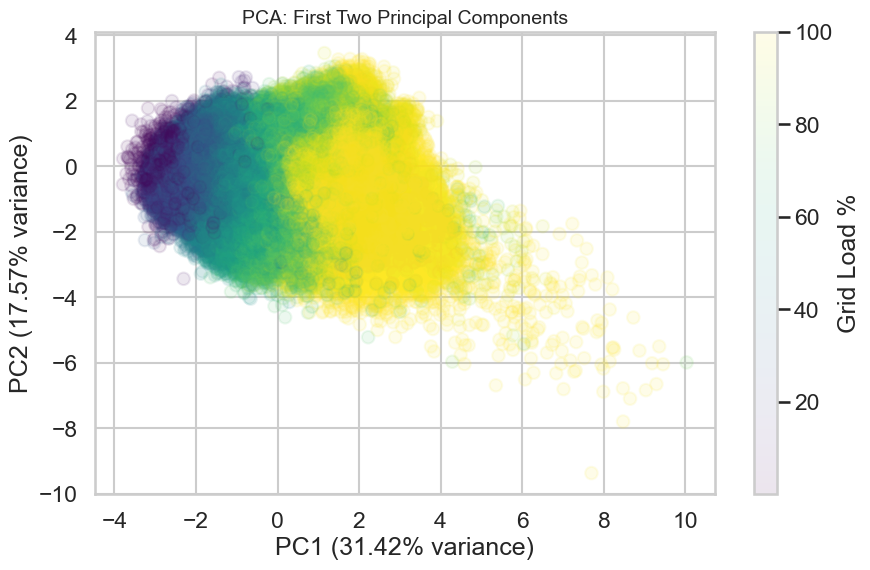

In [16]:
# 2. PCA Analysis
df_num = df[numerical_cols].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_num)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# PCA Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df['grid_load_pct'], cmap='viridis', alpha=0.1)
plt.colorbar(label='Grid Load %')
plt.title('PCA: First Two Principal Components', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.savefig(output_dir / 'pca_scatter.png')
plt.show()

### Principal Component Analysis (PCA): Simplifying Complexity
When we have 27 columns, it's hard to visualize everything. $PCA$ (Principal Component Analysis) compresses all that information into just two "Super Variables" (PC1 and PC2).
- Simple Insight: We managed to capture nearly $50\%$ of the total information in the dataset using just two axes.
- What we see: The PCA plot shows a distinct gradient. The color indicates Grid Load %. Since the colors transition smoothly from left to right, we know that the "Super Variables" we created are very good at predicting how stressed the power grid is.

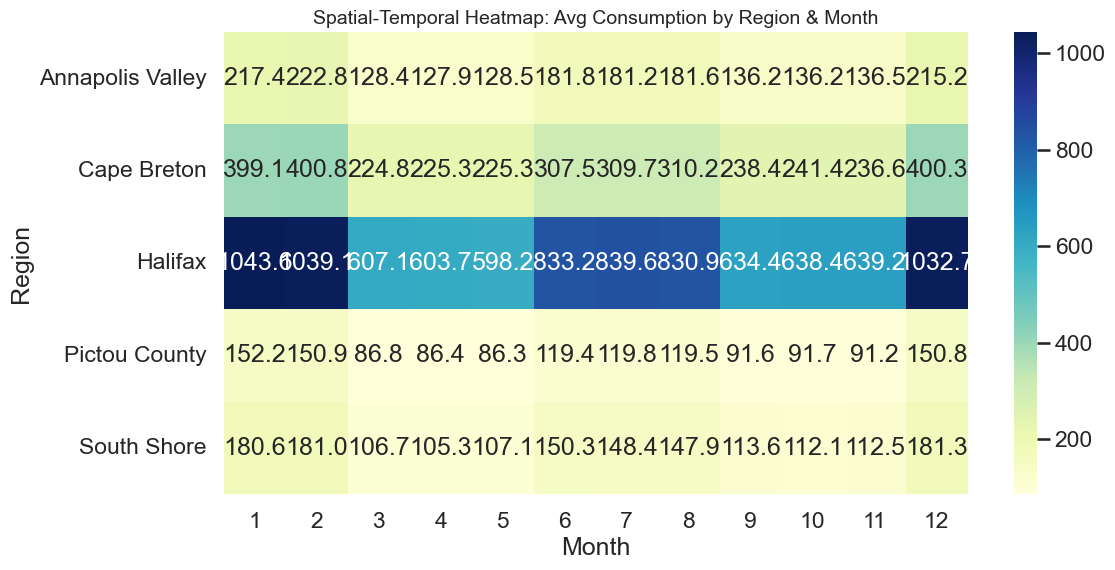

In [17]:
# 3. Spatial Analysis (Heatmap of Region vs Month)
pivot_region = df.groupby(['region', 'month'])['consumption_kwh'].mean().unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_region, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Spatial-Temporal Heatmap: Avg Consumption by Region & Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Region')
plt.savefig(output_dir / 'spatial_heatmap.png')
plt.show()

### Spatial-Temporal Analysis: Geographical Patterns
By combining Region (Space) and Month (Time) into a heatmap, we can see geographical trends.

- Simple Insight: Halifax is the undisputed "energy hub" of the dataset, consistently using much more power than regions like Pictou County or the South Shore.

- Seasonality: Every region follows the same seasonal cycle—usage is highest in the winter (Months 1-2 and 12) and drops significantly in the spring/fall.

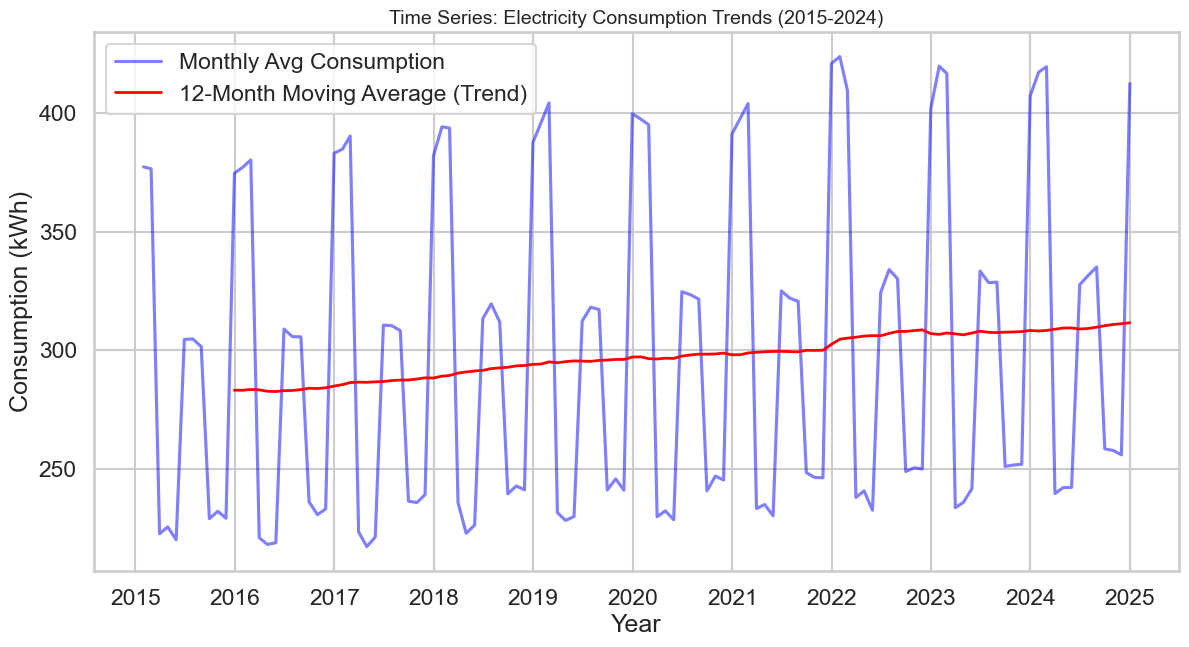

In [18]:
# 4. Time Series Analysis
# Resample to Monthly to see the trend and seasonality
ts_data = df.set_index('timestamp')['consumption_kwh'].resample('ME').mean().reset_index()
ts_data['moving_avg'] = ts_data['consumption_kwh'].rolling(window=12).mean() # 12-month moving average

plt.figure(figsize=(14, 7))
plt.plot(ts_data['timestamp'], ts_data['consumption_kwh'], label='Monthly Avg Consumption', alpha=0.5, color='blue')
plt.plot(ts_data['timestamp'], ts_data['moving_avg'], label='12-Month Moving Average (Trend)', color='red', linewidth=2)
plt.title('Time Series: Electricity Consumption Trends (2015-2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Consumption (kWh)')
plt.legend()
plt.savefig(output_dir / 'time_series_trend.png')
plt.show()

### Time Series Analysis: The Long-Term Trend
We plotted the consumption from 2015 to 2024 and added a 12-Month Moving Average (the red line).

- Simple Insight: While consumption goes up and down every season (the blue spikes), the Red Line is slowly creeping upward over the decade.

- Why it matters: This tells us that even after accounting for winter peaks, the overall demand for electricity is growing year-over-year. As a strategist, this means we need to plan for building more capacity for 2025 and beyond.

## Strategic Summary:
1. Halifax First: Since Halifax drives the majority of the load, grid optimization programs should start there for maximum impact.

2. Growth Trend: The moving average proves that "Business as Usual" isn't enough; the grid needs to expand to meet the decade-long growth in demand.

3. Customer Differentiation: The Pair Plot shows that different customers have different "fingerprints." We should offer tailored energy-saving plans for Residential vs. Commercial users rather than a one-size-fits-all approach.

1. **Temporal Variables (The Timeline)**

These variables anchor our data in time.

- Timestamp: The primary key. While currently stored as an object (text), we treat it as Datetime.

- Hour, Day, Month, Year: These are Cyclical Numerical values.

    - **Note**: Even though they are numbers, we often treat "Hour" as a category because Hour 23 (11 PM) is actually very close to Hour 0 (Midnight), just like Monday is close to Sunday.

2. **Numerical Variables (The Measurements)**

These are Continuous values where the distance between numbers matters (e.g., the difference between 10°C and 20°C is the same as 20°C to 30°C).

- Weather: temperature_c, humidity_pct, wind_speed_kmh, precipitation_mm.

- Grid Metrics: consumption_kwh, renewable_pct, grid_load_pct, price_per_kwh.

- Environmental Impact: co2_kg.

3. **Categorical Variables (The Labels)**

These variables represent groups or types. They are Nominal, meaning there is no inherent "order" (Halifax isn't "higher" than Cape Breton; they are just different).

- Identity: region, customer_type.

- Context: season.

- Event Type: anomaly_type (Normal, Spike, Drop, Sustained).

4. **Binary/Boolean Flags (The Switches)**

These are a special type of categorical data with only two states: 0 (No) or 1 (Yes).

- Calendar Events: is_weekend, is_holiday.

- Grid Events: power_outage, demand_response, peak_demand_flag.

- Quality Control: anomaly_flag.

## 5. Time-Series Reality Check
Filter the data for the 'Halifax' region and plot a line chart of the first 168 hours (one full week) of the dataset to verify the expected daily 'double-hump' consumption pattern (morning and evening peaks). Save the figure to the output directory.

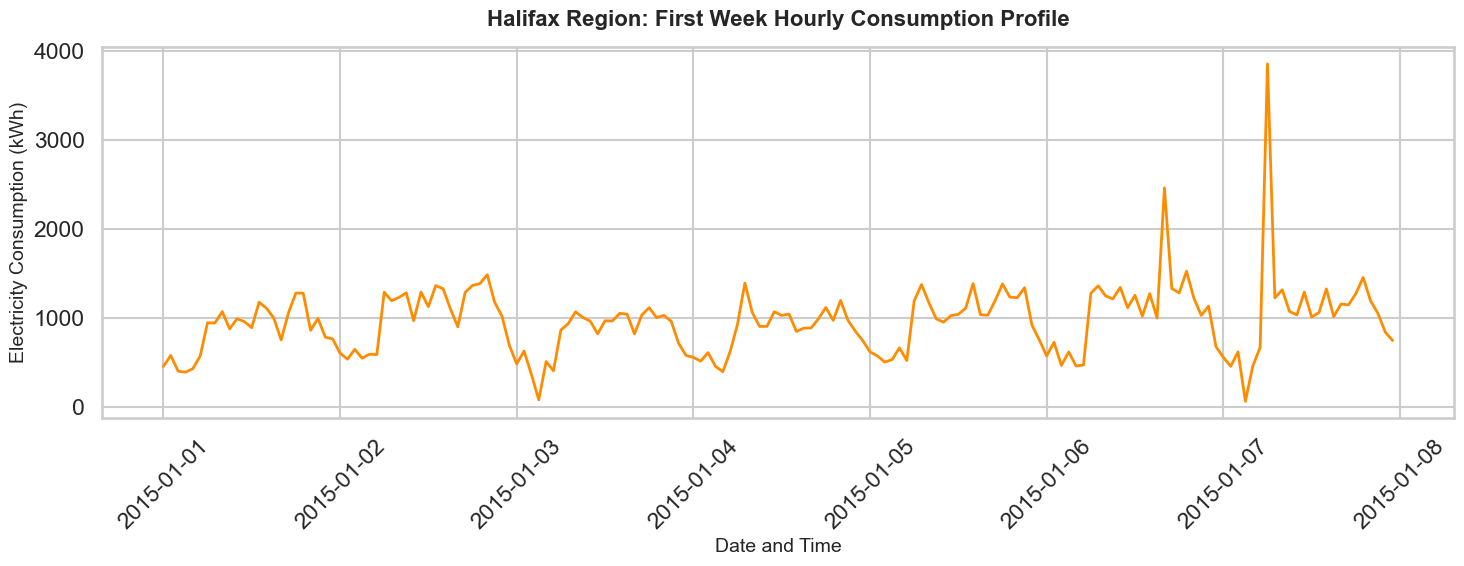

In [19]:
# Filter data for 'Halifax' region
df_halifax = df[df['region'] == 'Halifax'].copy()

# Sort by timestamp to ensure chronological order
df_halifax.sort_values(by="timestamp", inplace=True)

# Extract the first 168 hours (7 days * 24 hours)
df_halifax_week1 = df_halifax.head(168)

# Create the figure
plt.figure(figsize=(15, 6))

# Plot the line chart
sns.lineplot(data=df_halifax_week1, x="timestamp", y="consumption_kwh", color="darkorange", linewidth=2)

# Add professional titles and labels
plt.title("Halifax Region: First Week Hourly Consumption Profile", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Date and Time", fontsize=14)
plt.ylabel("Electricity Consumption (kWh)", fontsize=14)

# Enhance x-axis readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_dir / "halifax_week1_consumption.png", dpi=300, bbox_inches='tight')
plt.show()

## 6. Regional Heatmaps
Compare Halifax's consumption load against the other 4 regions (Annapolis Valley, Cape Breton, Pictou County, South Shore).

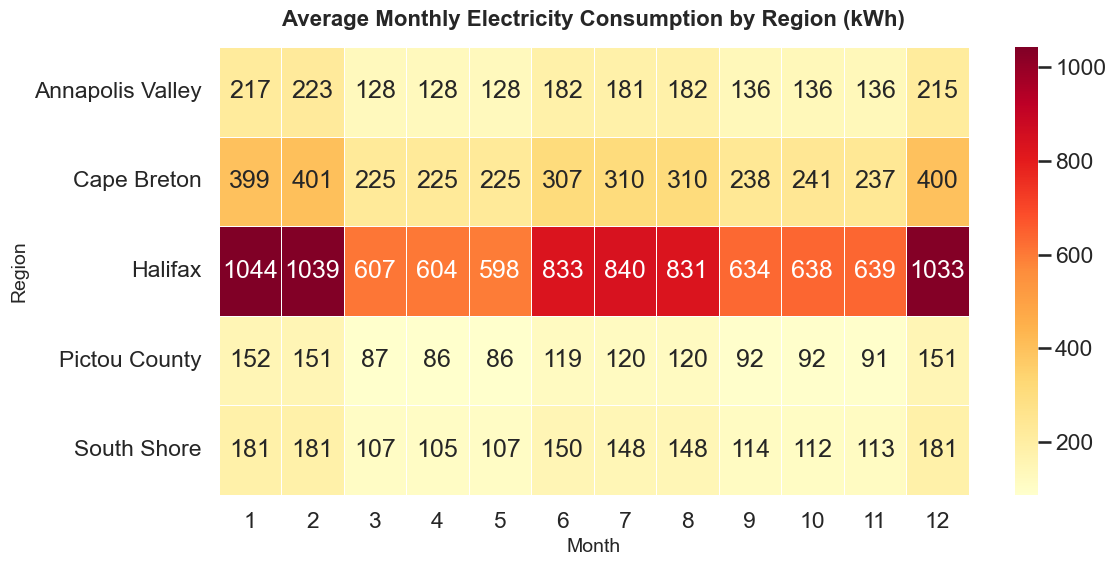

In [20]:
# Create a pivot table of average daily consumption by region and month
pivot_df = df.pivot_table(values='consumption_kwh', index='region', columns='month', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, cmap='YlOrRd', annot=True, fmt=".0f", linewidths=.5)
plt.title('Average Monthly Electricity Consumption by Region (kWh)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Region', fontsize=14)
plt.tight_layout()
plt.savefig(output_dir / 'regional_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation: Regional Heatmaps
- **Business Insight:** Halifax clearly dominates the consumption landscape, showing significantly higher absolute loads compared to the other four regions year-round. We also observe an intensification of demand during extreme winter and summer months across all regions, particularly in Halifax and Cape Breton.
- **Actionable Takeaway:** Grid maintenance and infrastructure upgrades should prioritize the Halifax corridor. Additionally, peak-shaving demand response programs will yield the highest absolute MW reductions if targeted specifically at Halifax during the mid-winter and mid-summer peaks.

## 7. Seasonal Decomposition
Separate the Halifax dataset into Trend, Seasonality, and Residuals (noise) to understand underlying patterns.

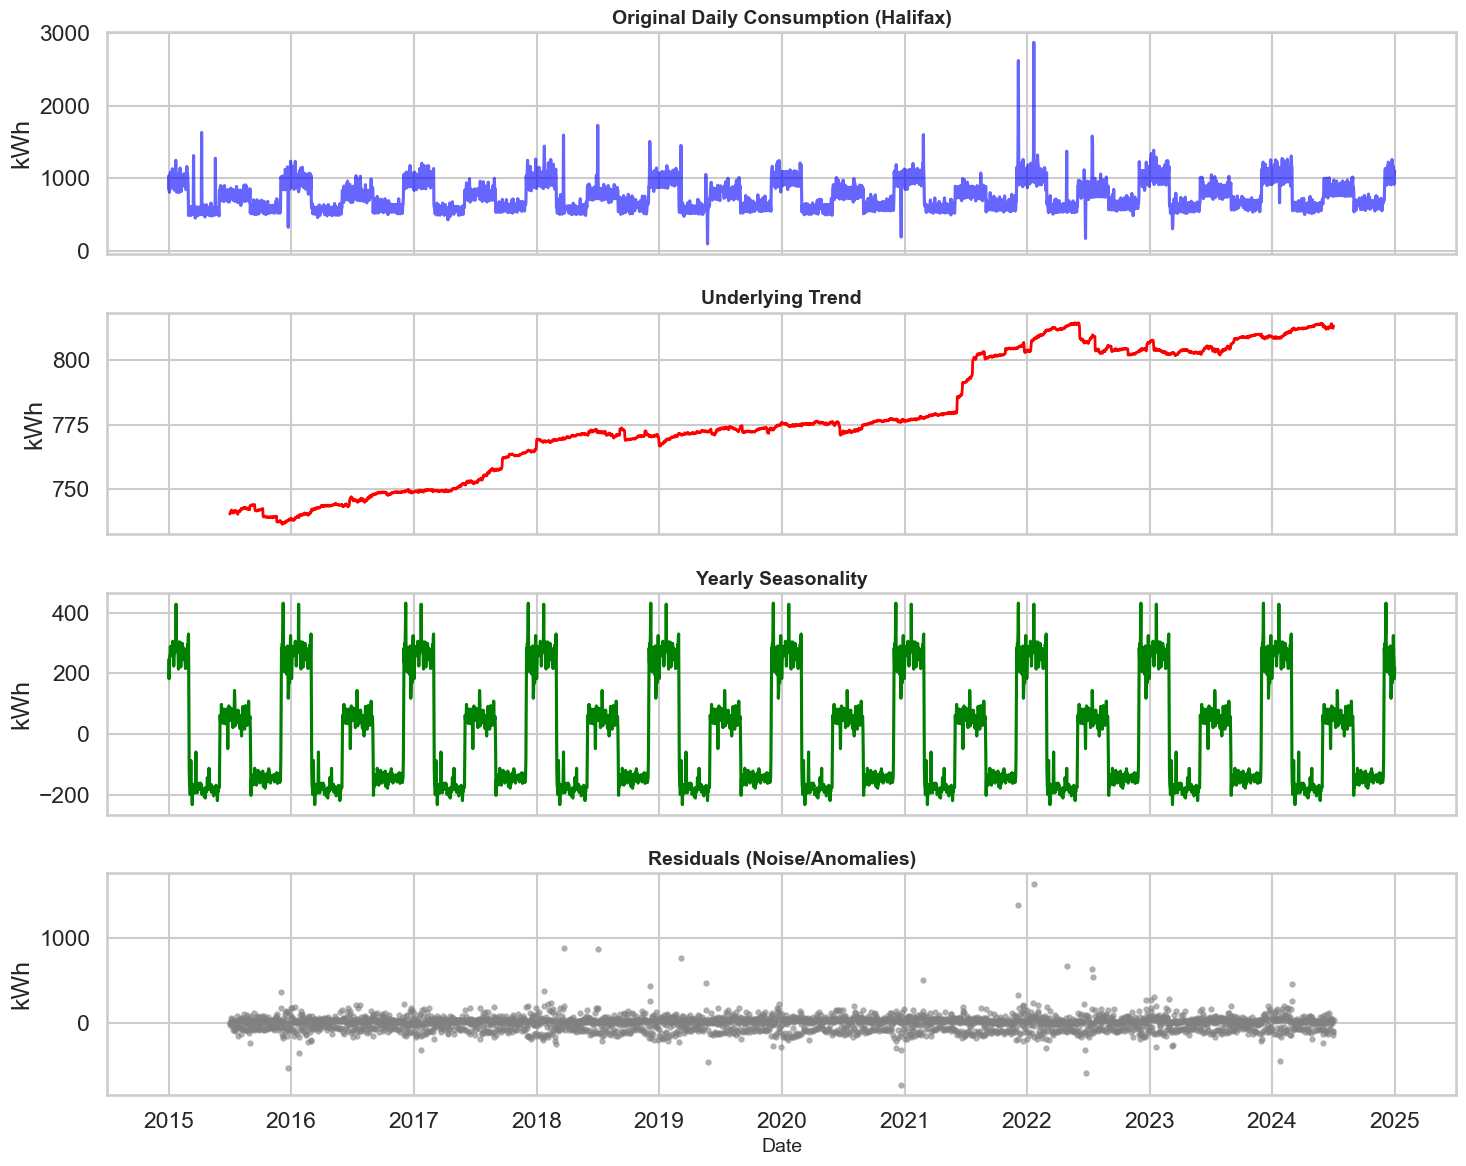

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Filter for Halifax and set timestamp as index
df_hfx = df[df['region'] == 'Halifax'].copy()
df_hfx.set_index('timestamp', inplace=True)
df_hfx.sort_index(inplace=True)

# Resample to daily average consumption to smooth hourly spikes for seasonal decomposition
df_hfx_daily = df_hfx['consumption_kwh'].resample('D').mean().dropna()

# Perform seasonal decomposition (assuming a yearly period of 365 days)
decomposition = seasonal_decompose(df_hfx_daily, model='additive', period=365)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

ax1.plot(df_hfx_daily.index, df_hfx_daily.values, color='blue', alpha=0.6)
ax1.set_title('Original Daily Consumption (Halifax)', fontsize=14, fontweight='bold')
ax1.set_ylabel('kWh')

ax2.plot(decomposition.trend.index, decomposition.trend.values, color='red', linewidth=2)
ax2.set_title('Underlying Trend', fontsize=14, fontweight='bold')
ax2.set_ylabel('kWh')

ax3.plot(decomposition.seasonal.index, decomposition.seasonal.values, color='green')
ax3.set_title('Yearly Seasonality', fontsize=14, fontweight='bold')
ax3.set_ylabel('kWh')

ax4.scatter(decomposition.resid.index, decomposition.resid.values, color='gray', alpha=0.5, s=10)
ax4.set_title('Residuals (Noise/Anomalies)', fontsize=14, fontweight='bold')
ax4.set_ylabel('kWh')

plt.xlabel('Date', fontsize=14)
plt.tight_layout()
plt.savefig(output_dir / 'seasonal_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation: Seasonal Decomposition
- **Business Insight:** The decomposition isolates the steady baseline growth (Trend) from the predictable yearly cyclical peaks (Seasonality). The 'Residuals' plot highlights unexpected demand spikes (noise) that the regular seasonal model cannot explain.
- **Actionable Takeaway:** Our anomaly detection model should focus precisely on these 'Residuals'. By stripping away predictable seasonal weather effects and general growth trends, we can accurately pinpoint true anomalous grid behavior, whether caused by equipment faults, unexpected extreme weather events, or sudden shifts in consumer behavior.

## 8. Holiday Impact Analysis
Analyze if `is_holiday` causes a significant drop in commercial demand vs. an increase in residential demand.

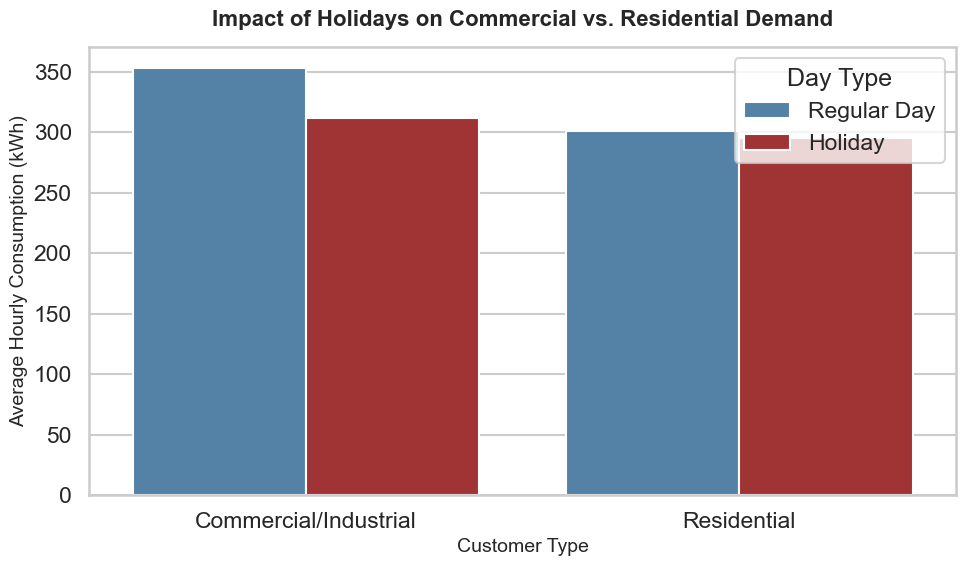

In [28]:
# Filter data for Commercial and Residential customers
df_cust = df[df['customer_type'].isin(['Commercial/Industrial', 'Residential'])].copy()

# Group by holiday status and customer type to get average consumption
holiday_impact = df_cust.groupby(['is_holiday', 'customer_type'])['consumption_kwh'].mean().reset_index()

# Map the holiday boolean to descriptive labels
holiday_impact['is_holiday'] = holiday_impact['is_holiday'].map({0: 'Regular Day', 1: 'Holiday'})

plt.figure(figsize=(10, 6))
sns.barplot(data=holiday_impact, x='customer_type', y='consumption_kwh', hue='is_holiday', palette={'Regular Day': 'steelblue', 'Holiday': 'firebrick'})
plt.title('Impact of Holidays on Commercial vs. Residential Demand', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Customer Type', fontsize=14)
plt.ylabel('Average Hourly Consumption (kWh)', fontsize=14)
plt.legend(title='Day Type')
plt.tight_layout()
plt.savefig(output_dir / 'holiday_impact.png', dpi=300, bbox_inches='tight')
plt.show()

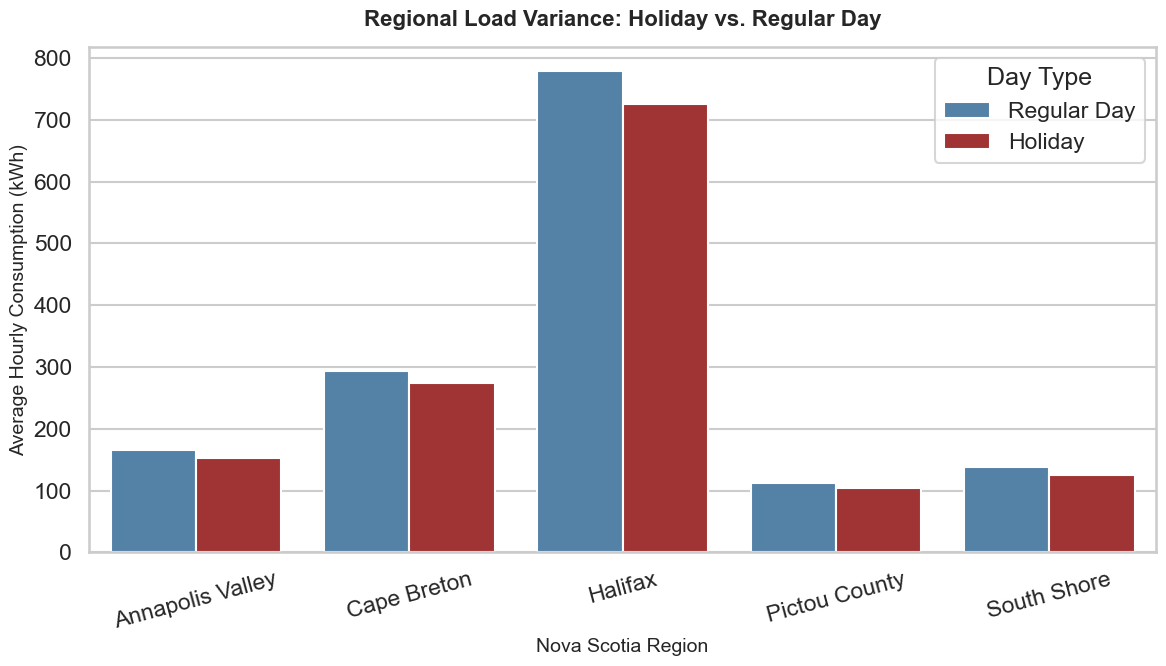

In [29]:
# 1. Group by holiday status and REGION to get average consumption
# We use the full df here to capture the total regional load
regional_holiday_impact = df.groupby(['is_holiday', 'region'])['consumption_kwh'].mean().reset_index()

# 2. Map the holiday boolean to descriptive labels for the legend
regional_holiday_impact['is_holiday'] = regional_holiday_impact['is_holiday'].map({0: 'Regular Day', 1: 'Holiday'})

# 3. Visualization
plt.figure(figsize=(12, 7))
sns.barplot(
    data=regional_holiday_impact, 
    x='region', 
    y='consumption_kwh', 
    hue='is_holiday', 
    palette={'Regular Day': 'steelblue', 'Holiday': 'firebrick'}
)

# 4. Professional Formatting
plt.title('Regional Load Variance: Holiday vs. Regular Day', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Nova Scotia Region', fontsize=14)
plt.ylabel('Average Hourly Consumption (kWh)', fontsize=14)
plt.legend(title='Day Type', loc='upper right')
plt.xticks(rotation=15) # Slight rotation for better readability of region names
plt.tight_layout()

# 5. Save the figure for your report
plt.savefig(output_dir / 'regional_holiday_impact.png', dpi=300, bbox_inches='tight')
plt.show()

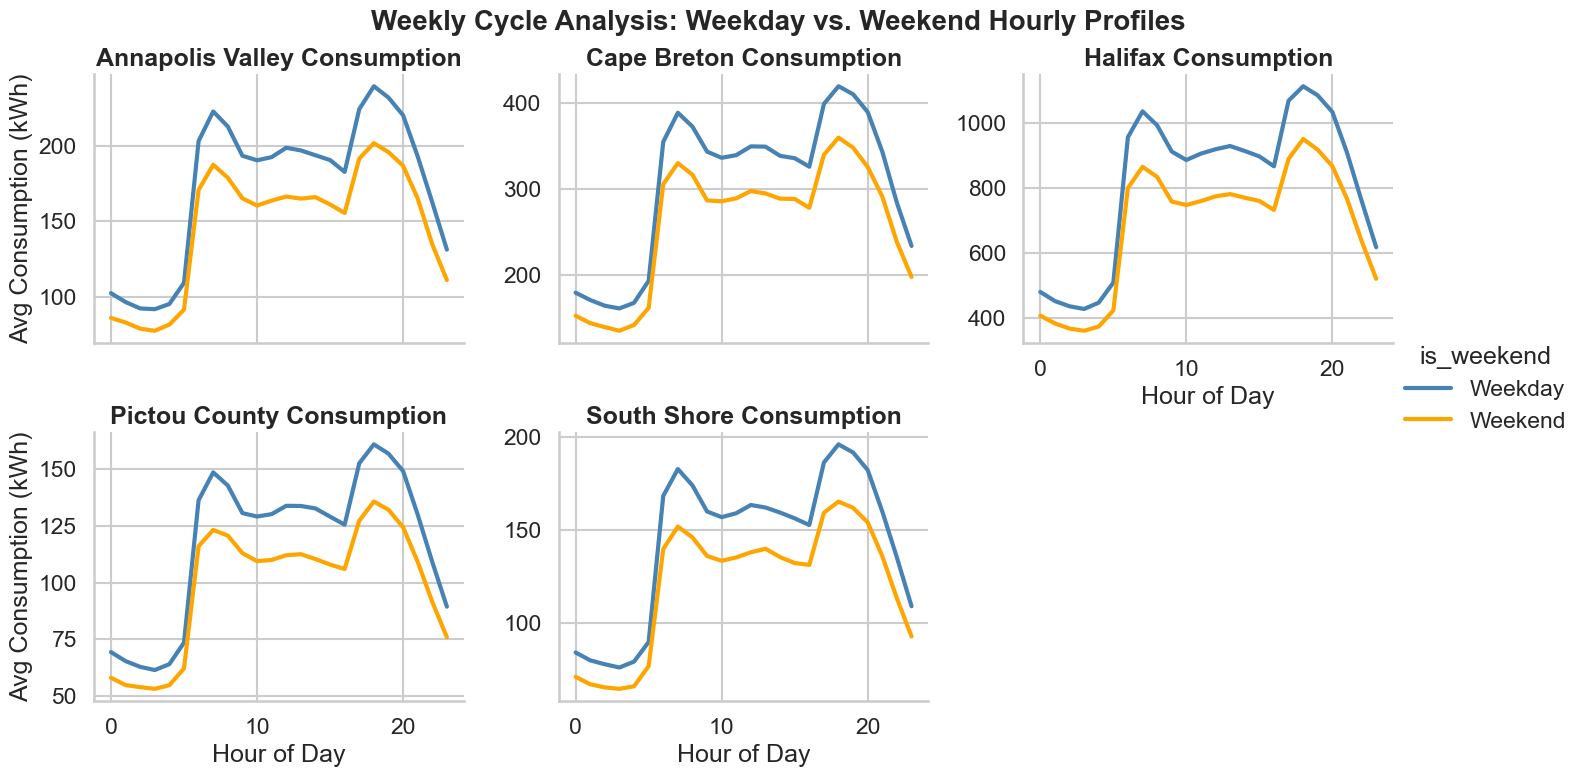

In [30]:
# 1. Group by Weekend status, Region, and Hour to get the average profile
weekend_profile = df.groupby(['is_weekend', 'region', 'hour'])['consumption_kwh'].mean().reset_index()

# 2. Map the boolean to descriptive labels
weekend_profile['is_weekend'] = weekend_profile['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

# 3. Use FacetGrid to show all 5 regions side-by-side
# We use 'col_wrap=3' to make a clean grid layout
g = sns.relplot(
    data=weekend_profile, 
    x='hour', y='consumption_kwh', 
    hue='is_weekend', col='region', 
    col_wrap=3,
    kind='line', linewidth=3,
    palette={'Weekday': 'steelblue', 'Weekend': 'orange'},
    height=4, aspect=1.2,
    facet_kws={'sharey': False} # Allows us to see the 'shape' of each region clearly
)

# 4. Professional Formatting
g.set_titles("{col_name} Consumption", fontweight='bold')
g.set_axis_labels("Hour of Day", "Avg Consumption (kWh)")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Weekly Cycle Analysis: Weekday vs. Weekend Hourly Profiles', fontsize=20, fontweight='bold')

# 5. Save for the report
plt.savefig(output_dir / 'weekend_vs_weekday_profile.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation: Holiday Impact Analysis
- **Business Insight:** The bar chart effectively illustrates a structural demand shift during statutory holidays. Commercial electricity consumption drops significantly as businesses close, while Residential consumption sees a reciprocal increase due to people staying home.
- **Actionable Takeaway:** This confirms `is_holiday` is a critical covariate for our predictive models. The grid must re-route base load expectations on holidays. Anomaly detection models must be aware of this shift; otherwise, the drop in commercial load might trigger a false 'power outage' alert, or the spike in residential load might trigger a false 'surge' alert.

## 5. Feature Engineering
Preparing the data for advanced modeling (e.g., ARIMA, LSTM). We already converted the timestamp to datetime when loading the dataset.

### 5.1 Lag Features
Creating lag variables to capture temporal dependencies.

In [23]:
# Sort data chronologically within each region before shifting
df = df.sort_values(by=['region', 'timestamp'])

# Create 1-hour and 24-hour lag features for consumption
df['consumption_kwh_lag_1h'] = df.groupby('region')['consumption_kwh'].shift(1)
df['consumption_kwh_lag_24h'] = df.groupby('region')['consumption_kwh'].shift(24)

print("Created Lag Features: 'consumption_kwh_lag_1h' and 'consumption_kwh_lag_24h'")
display(df[['timestamp', 'region', 'consumption_kwh', 'consumption_kwh_lag_1h', 'consumption_kwh_lag_24h']].head())

Created Lag Features: 'consumption_kwh_lag_1h' and 'consumption_kwh_lag_24h'


,timestamp,region,consumption_kwh,consumption_kwh_lag_1h,consumption_kwh_lag_24h
0,2015-01-01 00:00:00,Annapolis Valley,125.53,NaN,NaN
5,2015-01-01 01:00:00,Annapolis Valley,94.93,125.53,NaN
10,2015-01-01 02:00:00,Annapolis Valley,103.48,94.93,NaN
15,2015-01-01 03:00:00,Annapolis Valley,82.12,103.48,NaN
20,2015-01-01 04:00:00,Annapolis Valley,81.56,82.12,NaN


In [31]:
# Check how many NaNs we have before dropping
print(f"Total NaNs before cleaning: {df.isna().sum().sum()}")

# Drop the rows where we don't have enough history to calculate lags
df = df.dropna().reset_index(drop=True)

# Verify cleaning
print(f"Total NaNs after cleaning: {df.isna().sum().sum()}")
print(f"Remaining rows for modeling: {len(df)}")
display(df[['timestamp', 'region', 'consumption_kwh', 'consumption_kwh_lag_1h', 'consumption_kwh_lag_24h']].head())

Total NaNs before cleaning: 125
Total NaNs after cleaning: 0
Remaining rows for modeling: 438240


,timestamp,region,consumption_kwh,consumption_kwh_lag_1h,consumption_kwh_lag_24h
0,2015-01-02 00:00:00,Annapolis Valley,114.19,125.58,125.53
1,2015-01-02 01:00:00,Annapolis Valley,113.90,114.19,94.93
2,2015-01-02 02:00:00,Annapolis Valley,96.57,113.90,103.48
3,2015-01-02 03:00:00,Annapolis Valley,112.05,96.57,82.12
4,2015-01-02 04:00:00,Annapolis Valley,124.48,112.05,81.56


### 5.2 Weather Interaction Features
Creating a 'Heating Degree Day' (HDD) feature to capture the non-linear impact of cold weather on electricity demand.

In [24]:
# Calculate Heating Degree Day (HDD) with a base temperature of 18 degrees Celsius
# When temperature is below 18C, heating is usually required.
df['hdd'] = (18 - df['temperature_c']).clip(lower=0)

print("Created Weather Interaction Feature: 'hdd' (Heating Degree Day)")
display(df[['timestamp', 'temperature_c', 'hdd']].head())

Created Weather Interaction Feature: 'hdd' (Heating Degree Day)


,timestamp,temperature_c,hdd
0,2015-01-01 00:00:00,-10.1,28.1
5,2015-01-01 01:00:00,23.4,0.0
10,2015-01-01 02:00:00,-7.3,25.3
15,2015-01-01 03:00:00,3.6,14.4
20,2015-01-01 04:00:00,14.2,3.8


### 5.3 Categorical Encoding
One-hot encoding 'region' and 'customer_type' for modeling algorithms that require numerical input.

In [32]:
# One-hot encode regions and customer types
df_encoded = pd.get_dummies(df, columns=['region', 'customer_type'], drop_first=False)

print(f"Original columns: {len(df.columns)}")
print(f"Encoded columns: {len(df_encoded.columns)}")
print("New encoded columns added:")
print([col for col in df_encoded.columns if col not in df.columns])

display(df_encoded.head())

Original columns: 30
Encoded columns: 36
New encoded columns added:
['region_Annapolis Valley', 'region_Cape Breton', 'region_Halifax', 'region_Pictou County', 'region_South Shore', 'customer_type_Commercial/Industrial', 'customer_type_Mixed', 'customer_type_Residential']


,timestamp,hour,day_of_week,month,year,week,is_weekend,season,is_holiday,temperature_c,...,consumption_kwh_lag_24h,hdd,region_Annapolis Valley,region_Cape Breton,region_Halifax,region_Pictou County,region_South Shore,customer_type_Commercial/Industrial,customer_type_Mixed,customer_type_Residential
0,2015-01-02 00:00:00,0,4,1,2015,1,0,Winter,0,-8.8,...,125.53,26.8,True,False,False,False,False,False,True,False
1,2015-01-02 01:00:00,1,4,1,2015,1,0,Winter,0,8.5,...,94.93,9.5,True,False,False,False,False,False,True,False
2,2015-01-02 02:00:00,2,4,1,2015,1,0,Winter,0,2.2,...,103.48,15.8,True,False,False,False,False,False,True,False
3,2015-01-02 03:00:00,3,4,1,2015,1,0,Winter,0,-1.8,...,82.12,19.8,True,False,False,False,False,False,True,False
4,2015-01-02 04:00:00,4,4,1,2015,1,0,Winter,0,-6.2,...,81.56,24.2,True,False,False,False,False,False,True,False
